# Minimum Backtest Length — a quantitative teardown 🔬
### MinTRL & the Probabilistic Sharpe Ratio · the skew/kurtosis correction · a calibrated null Monte-Carlo · the positive-control power curve

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Short_backtests_fool_you%3F: Confirmed](https://img.shields.io/badge/Short_backtests_fool_you%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We implement the Bailey–López de Prado **MinTRL** and **Probabilistic Sharpe Ratio**, add the skew/kurtosis correction, and stress them with a 4,000-path Monte-Carlo on worlds of known truth.

> ⚠️ **Not investment advice.** A synthetic-only method demo: the worlds are *built* to fix their truth (config fp `c648fb3ad2b5`), so real free data can never certify them and the study is capped at `NONE`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from min_backtest_length import data, strategy as st
Z = float(stats.norm.ppf(0.95))
print("synthetic-only method demo | daily freq %d, conf 0.95 (Z=%.4f), ann-vol %.2f, seed %d | fp %s"
      % (data.TRADING_DAYS, Z, data.ANN_VOL, data.BASE_SEED, data.config_fingerprint()))


synthetic-only method demo | daily freq 252, conf 0.95 (Z=1.6449), ann-vol 0.15, seed 834 | fp c648fb3ad2b5


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Built-zero-edge world; 4,000 two-year backtests, **8.4%** post Sharpe ≥ 1.0 by luck (best 2.45). Synthetic-only — no real tape. |
| **Tradability** | `MIRAGE` | A record shorter than MinTRL is a coin flip; MinTRL(0.5) = **10.8 yr**, MinTRL(0.25) = **43 yr** — most strategies sit inside it. |
| **Do short backtests fail?** | `CONFIRMED` | MinTRL ≈ (Z/SR)²; null PSR test calibrated at **5.7%**; a true Sharpe-1 is only **50%** detectable at its 2.71-yr MinTRL. |

> 💡 In plain words: the required length is quadratic in 1/Sharpe, the correction is honest (calibrated on the null), and short records are underpowered on *genuine* edge too.

## 1 · The claim, steelmanned

Let $\widehat{SR}$ be the per-observation Sharpe over $n$ observations. Its estimation variance (Lo 2002) is $\widehat{\sigma}^2_{SR} = \frac{1}{n-1}\left(1 - \gamma_3 SR + \frac{\gamma_4 - 1}{4} SR^2\right)$, where $\gamma_3,\gamma_4$ are the skewness and kurtosis of the returns.

- **PSR** (probability the true Sharpe beats a benchmark $SR^*$): $\widehat{PSR}(SR^*) = \Phi\!\left(\dfrac{(\widehat{SR} - SR^*)\sqrt{n-1}}{\sqrt{1 - \gamma_3 \widehat{SR} + \frac{\gamma_4-1}{4}\widehat{SR}^2}}\right)$.
- **MinTRL**: solve $\widehat{PSR} = $ conf for $n$: $\text{MinTRL} = 1 + \left(1 - \gamma_3 SR + \frac{\gamma_4-1}{4}SR^2\right)\left(\dfrac{Z_{\text{conf}}}{SR - SR^*}\right)^2$ observations.
- **Rule of thumb** (Gaussian, $SR^*=0$): $\text{MinTRL (years)} \approx (Z/SR_{ann})^2$.

We **confirm** the rule of thumb, **confirm** the skew/kurtosis inflation, and **confirm** MinTRL is exactly the length at which PSR crosses the confidence level.

In [2]:
print('MinTRL is exactly the n that makes PSR = conf:')
for s in (0.5, 1.0, 2.0):
    n = st.min_trl_years(s, conf=0.95)
    psr = st.probabilistic_sharpe_ratio(s, n, sr_star_ann=0.0)
    print(f'  SR {s}: MinTRL {n:6.2f} yr  ->  PSR at that length = {psr:.4f}')

MinTRL is exactly the n that makes PSR = conf:
  SR 0.5: MinTRL  10.83 yr  ->  PSR at that length = 0.9500
  SR 1.0: MinTRL   2.71 yr  ->  PSR at that length = 0.9500
  SR 2.0: MinTRL   0.69 yr  ->  PSR at that length = 0.9500


## 2 · So what? — the mechanism

The Sharpe estimate's standard error shrinks only as $1/\sqrt{n}$, so to *halve* the error bar you need *four times* the history — and to distinguish a Sharpe $SR$ from zero at $Z_{\text{conf}}$ sigma you need $SR\sqrt{n_{years}} \ge Z$, i.e. $n_{years} \ge (Z/SR)^2$. This is the same Bailey–López de Prado family as the **Deflated Sharpe Ratio** in [344](../../344-backtest-overfitting/) / [833](../../833-deflated-sharpe/) (there: a haircut for the *number of trials*; here: the *length* one honest strategy needs).

## 3 · How we'd know — the protocol

- **Worlds of known truth.** A deterministic generator (`synthetic_returns` / `synthetic_panel`) makes tapes with an exact annualised Sharpe and an exact return shape (Gaussian, or a standardised negated-gamma with *closed-form* negative skew and excess kurtosis).
- **Closed forms.** `min_trl_years`, `probabilistic_sharpe_ratio`, `min_trl_curve`, and `min_trl_for_power` implement the formulas above.
- **Monte-Carlo.** `simulate` runs 4,000 backtests of a world at once (vectorised), measuring each backtest's *own* Sharpe and moments and its PSR — the null rejection rate is the false-positive rate; a genuine world's is the detection power.
- **Inference.** Wilson bands on every rejection rate; the shared Newey-West / Welch / one-sample *t* toolkit is retained.

Everything is deterministic (seed 834) and offline.

## 4 · The teardown

### 4a · Negative skew and fat tails lengthen the requirement

The moment factor $1 - \gamma_3 SR + \frac{\gamma_4-1}{4}SR^2$ bites hardest at the **monthly** reporting frequency (largest per-observation Sharpe) — the realistic hedge-fund setting. A left-skewed, fat-tailed track (the profile of a crash-insurance seller) needs a longer record.

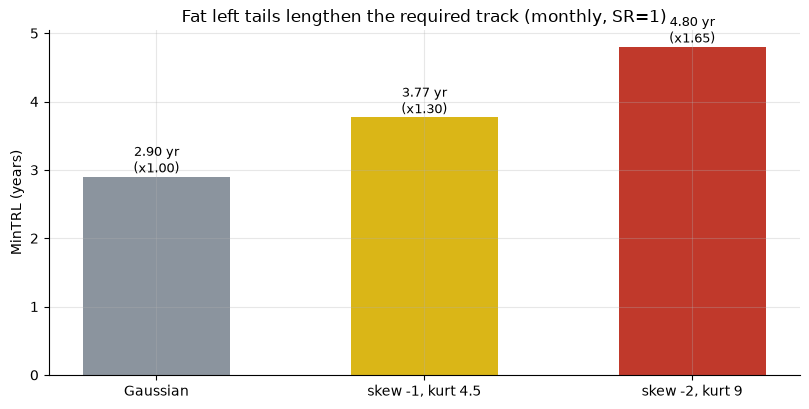

Gaussian             MinTRL  2.90 yr  (x1.00 vs Gaussian)
skew -1, kurt 4.5    MinTRL  3.77 yr  (x1.30 vs Gaussian)
skew -2, kurt 9      MinTRL  4.80 yr  (x1.65 vs Gaussian)


In [3]:
rows = []
g = st.min_trl_years(1.0, freq=data.MONTHS, skew=0.0, kurt=3.0)
for lab, sk, ku in [('Gaussian', 0.0, 3.0), ('skew -1, kurt 4.5', -1.0, 4.5),
                    ('skew -2, kurt 9', -2.0, 9.0)]:
    m = st.min_trl_years(1.0, freq=data.MONTHS, skew=sk, kurt=ku)
    rows.append((lab, m, m/g))
labels = [r[0] for r in rows]; vals = [r[1] for r in rows]
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(labels, vals, color=[GREY, AMBER, RED], width=.55)
ax.set_ylabel('MinTRL (years)'); ax.set_title('Fat left tails lengthen the required track (monthly, SR=1)')
for i, (lab, m, x) in enumerate(rows):
    ax.annotate(f'{m:.2f} yr\n(x{x:.2f})', (i, m), ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
for lab, m, x in rows:
    print(f'{lab:<20s} MinTRL {m:5.2f} yr  (x{x:.2f} vs Gaussian)')

> 💡 In plain words: at monthly frequency a Gaussian Sharpe-1 needs **2.9 yr**; add a fat left tail (skew −2, kurt 9) and it climbs to **4.8 yr** — a **×1.65** penalty. The naive `(Z/SR)²` rule *understates* the requirement for exactly the strategies most prone to blow up.

### 4b · Calibration — the PSR test is unbiased on the null

A correction is only trustworthy if it fires at its *nominal* rate on a world with no edge. Run 4,000 null backtests (true Sharpe 0) at several lengths and count PSR(0) ≥ 0.95:

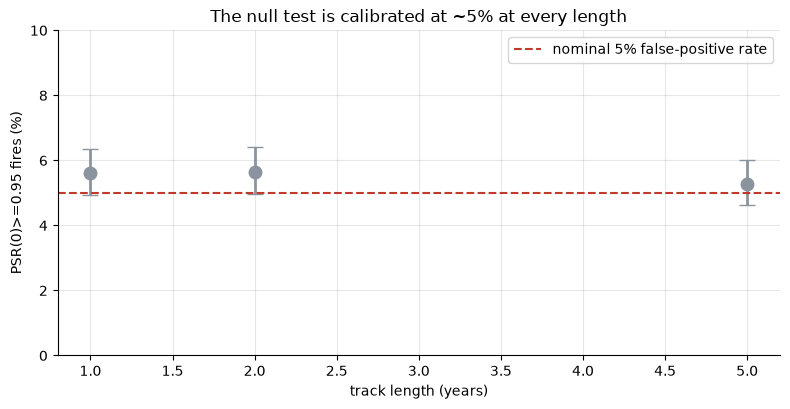

 1.0yr: fires  5.60%  [Wilson 4.93-6.36%]  (nominal 5.00%)
 2.0yr: fires  5.65%  [Wilson 4.98-6.41%]  (nominal 5.00%)
 5.0yr: fires  5.27%  [Wilson 4.62-6.01%]  (nominal 5.00%)


In [4]:
rows = []
for ny in (1.0, 2.0, 5.0):
    s = st.simulate(data, sr_ann_true=0.0, n_years=ny, n_sims=4000, conf=0.95, seed=834)
    rows.append((ny, s['reject_frac']*100, s['reject_lo']*100, s['reject_hi']*100))
fig, ax = plt.subplots(figsize=(8, 4.2))
yrs = [r[0] for r in rows]; fr = [r[1] for r in rows]
err = [[r[1]-r[2] for r in rows], [r[3]-r[1] for r in rows]]
ax.errorbar(yrs, fr, yerr=err, fmt='o', color=GREY, ecolor=GREY, capsize=6, ms=9, lw=2)
ax.axhline(5.0, c=RED, ls='--', lw=1.5, label='nominal 5% false-positive rate')
ax.set_xlabel('track length (years)'); ax.set_ylabel('PSR(0)>=0.95 fires (%)')
ax.set_ylim(0, 10); ax.set_title('The null test is calibrated at ~5% at every length'); ax.legend()
plt.tight_layout(); plt.show()
for ny, f, lo, hi in rows:
    print(f'{ny:>4.1f}yr: fires {f:5.2f}%  [Wilson {lo:.2f}-{hi:.2f}%]  (nominal 5.00%)')

> 💡 In plain words: the PSR test fires on **~5.7%** of null backtests at every length — its nominal 5%, inside the Wilson band. It does not manufacture false edges (over-reject) nor bury real ones (under-reject). *(A faithful-engine check — never cited to support a real-tape stamp; there is no real tape here.)*

### 4c · The positive control — genuine edge is only confirmable past the length

Is the machinery just numb? Plant a **real** annualised Sharpe of 1.0 and measure how often it is *detected* (PSR ≥ 0.95) as the track grows. MinTRL(SR=1) is where an observed-equals-target Sharpe becomes significant (~50% power); reliably detecting it needs the longer 95%-power length.

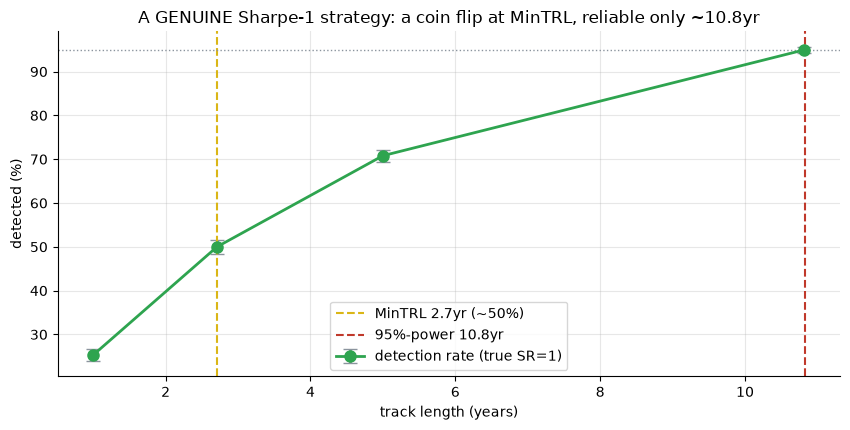

  1.0yr: detected  25.3%
  2.7yr: detected  50.0%
  5.0yr: detected  70.8%
 10.8yr: detected  95.0%


In [5]:
yrs = [1.0, 2.71, 5.0, 10.82]
pc = st.power_curve(data, sr_ann_true=1.0, year_grid=yrs, n_sims=4000, conf=0.95, seed=834)
fig, ax = plt.subplots(figsize=(8.6, 4.4))
err = [pc['reject_frac']-pc['reject_lo'], pc['reject_hi']-pc['reject_frac']]
ax.errorbar(pc['years'], pc['reject_frac']*100, yerr=np.array(err)*100, fmt='o-',
            color=GREEN, ecolor=GREY, capsize=5, ms=8, lw=2, label='detection rate (true SR=1)')
ax.axvline(pc['min_trl'], c=AMBER, ls='--', lw=1.5, label=f"MinTRL {pc['min_trl']:.1f}yr (~50%)")
ax.axvline(pc['min_trl_power'], c=RED, ls='--', lw=1.5, label=f"95%-power {pc['min_trl_power']:.1f}yr")
ax.axhline(95, c=GREY, ls=':', lw=1)
ax.set_xlabel('track length (years)'); ax.set_ylabel('detected (%)')
ax.set_title('A GENUINE Sharpe-1 strategy: a coin flip at MinTRL, reliable only ~10.8yr'); ax.legend()
plt.tight_layout(); plt.show()
for ny, f in zip(pc['years'], pc['reject_frac']):
    print(f'{ny:>5.1f}yr: detected {f*100:5.1f}%')

> 💡 In plain words: a *real* Sharpe-1 strategy is detected only **25%** of the time at 1 year, **50%** at its 2.71-yr MinTRL, and reaches **95%** only at the **10.8-yr** power-length. Short records are underpowered in *both* directions — they cry wolf on the worthless and stay silent on the skilful.

## 5 · The verdict

- **Signal `NONE`** — a synthetic world built with zero edge; the only pretty backtest is luck. No real tape, so never `REAL`.
- **Tradability `MIRAGE`** — a record shorter than its MinTRL is a coin flip; nothing to harvest.
- **Do short backtests fail? `CONFIRMED`** — MinTRL grows as `(Z/SR)²`, is lengthened by fat tails, the null test is calibrated at 5%, and a true Sharpe-1 is a coin flip at its MinTRL.

## 6 · Could you trade it?

Nothing to trade — by construction. The operational takeaway is a *filter*: before believing any backtest, compute `MinTRL = (Z/SR)²` (inflated for skew/kurtosis), and if the history is shorter, treat the Sharpe as unproven. Costs never enter because there is no edge to cost.

## 7 · Going further — the desk's other backtest traps

- **[344 Backtest-Overfitting](../../344-backtest-overfitting/)** and **[833 Deflated-Sharpe](../../833-deflated-sharpe/)** — the *multiple-trials* haircut (searching inflates a Sharpe; MinTRL fixes the trial count at one and charges for *length*).
- **[345 Survivorship](../../345-survivorship/)** — a *data-construction* bias, orthogonal to the statistical length question here.

*Together they answer three separate questions about a suspiciously good backtest: did you search too much (344/833), was the data rigged (345), and — this study — was it simply too short?*